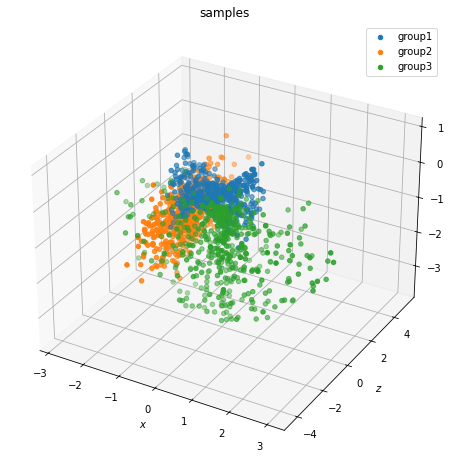

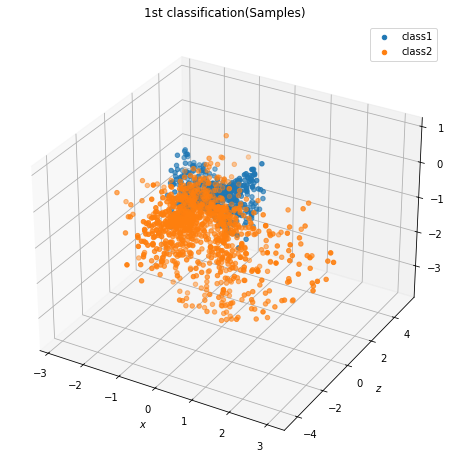

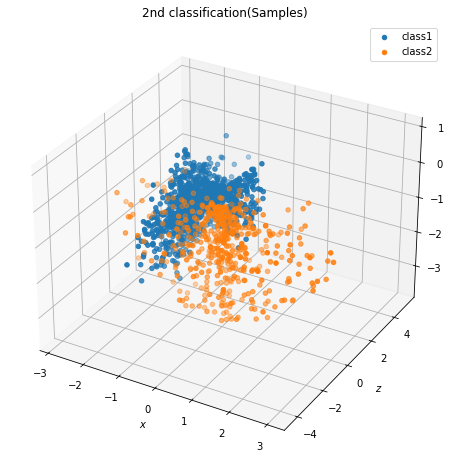

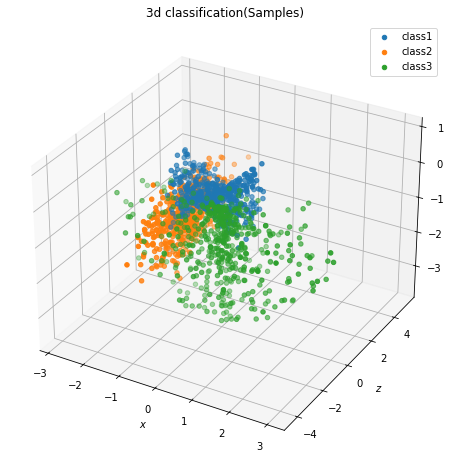

CLF_1:
accuracy = 0.936
precision = 0.9360450082993436
recall = 0.936
SVC_1:
accuracy = 0.9353333333333333
precision = 0.9351927232524248
recall = 0.9353333333333333
LDA_1:
accuracy = 0.9346666666666666
precision = 0.9351778635290148
recall = 0.9346666666666666
CLF_2:
accuracy = 0.8306666666666667
precision = 0.8277948375802262
recall = 0.8306666666666667
SVC_2:
accuracy = 0.8366666666666667
precision = 0.8350963694431356
recall = 0.8366666666666667
LDA_2:
accuracy = 0.8393333333333334
precision = 0.8452508899102849
recall = 0.8393333333333334
CLF_3:
accuracy = 0.8646666666666667
precision = 0.8667613147208795
recall = 0.8646666666666667
SVC_3:
accuracy = 0.8946666666666667
precision = 0.9037299797602755
recall = 0.8946666666666667
LDA_3:
accuracy = 0.8446666666666667
precision = 0.8653161925733752
recall = 0.8446666666666667
New CLF:
accuracy = 0.6006666666666667
precision = 0.938770250154935
recall = 0.6006666666666667
New SVC:
accuracy = 0.6666666666666666
precision = 0.932907557520

In [2]:
'''
Работа 2: Простейшие виды классификации
Типы входных данных:
Задание 1. По номеру варианта определить из таблицы 1 типы входных данных, которые
надо программно сгенерировать для дальнейшей обработки, и номера алгоритмов, которые
следует применить к этим данным.

A.Точки вида (a, b − 0.5, aε), где значения a, b, ε — 
независимые случайные числа, равномерно распределённые 
на отрезке [−1, 1]

B. Точки вида (0.1a − 1, 3b, ε − 1), где значения a, b, ε —
независимые случайные числа, нормально распределённые со 
средним значением 0 и среднеквадратическим отклонением 0.5

C. Случайные точки трехмерного пространства, распределённые по поверхности 
нижней полусферы с уравнением x^2 + y^2 + (z + 0.5)^2 = 1, 
z ≤ 0 (способ распределения произвольный)

Задание 2. Определить из таблицы 2 виды входных данных, которые должны быть обработаны, и сгенерировать их. В обучающую выборку включаются три указанные группы точек
трехмерного пространства; каждую из классификаций следует провести три раза:
1. включив в один класс первую группу точек, в другой — вторую и третью;
2. включив в один класс первую и вторую группы точек, в другой — третью;
3. включив каждую группу точек в свой отдельный класс.

Задание 3. Определить по таблице 3 методы обработки данных. Следует обработать каждую из выборок двумя указанными методами и сравнить качество полученных моделей (как
минимум, precision и recall для каждого из классов). Значения настроечных коэффициентов,
если они требуются, следует выбрать самостоятельно; нулевые значения этих коэффициентов
не допускаются.

Алгоритмы обработки:

1. Линейная пороговая классификация
2. Логистическая регрессия
3. Линейный дискриминант Фишера

Задание 4. Сгенерировать новую выборку данных такого же размера, включив в один класс
первую группу прецедентов, в другой — вторую и третью (так, как в задании 2 была получена
первая из тестовых выборок). Послее этого сравнить точность всех моделей на новой выборке и первой из прежних. Сделать вывод о сохранении точностных характеристик каждой из
моделей.

'''

# импортируем используемые библиотеки:
import numpy as np # базовая библиотека для численных методов
import sklearn.linear_model  # библиотека линейных моделей (в т.ч. линейной регрессии)
import matplotlib.pyplot as plt  # библиотека для вывода данных
from mpl_toolkits.mplot3d import axes3d, Axes3D  # дополнительные библиотеки
from sklearn.metrics import mean_squared_error  # для 3D визуализации

def generate_samples(NumSamples = 500):
    ''' функция генерации требуемой выборки;
    NumSamples --- её размер ''' 
    a = np.random.uniform(low=-1, high=1, size=(NumSamples, 1))
    b = np.random.uniform(low=-1, high=1, size=(NumSamples, 1))
    epsilon = np.random.uniform(low=-1, high=1, size=(NumSamples, 1))
    group1 = np.concatenate((a, b-0.5, epsilon*a), axis=1)
    
    a = np.random.normal(loc=0, scale=0.5, size=(NumSamples, 1)) 
    b = np.random.normal(loc=0, scale=0.5, size=(NumSamples, 1)) 
    epsilon = np.random.normal(loc=0, scale=0.5, size=(NumSamples, 1)) 
    group2 = np.concatenate((0.1*a-1, 3*b, epsilon-1), axis=1)

    theta = np.random.uniform(low=0, high=np.pi/2, size=(NumSamples, 1))
    phi = np.random.uniform(low=0, high=2*np.pi, size=(NumSamples, 1))
    R = np.random.uniform(low=-np.pi, high=0, size=(NumSamples, 1))
    x = R*np.cos(theta)*np.cos(phi);
    y = R*np.cos(theta)*np.sin(phi);
    z = R*np.sin(theta)
    group3 = np.concatenate((x, y, z -0.5), axis=1)
    return group1, group2, group3

# Б. Функция для вывода выборки
def draw_samples(group, ax, label=None):
    ax.scatter(group[:,0], group[:,1], group[:, 2], label=label)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')
    ax.set_ylabel(r'$z$')

group1, group2, group3 = generate_samples()

class11 = group1
mark_of_11st_class = np.zeros(len(class11))
class12 = np.concatenate((group2, group3), axis=0)
mark_of_12nd_class = np.ones(len(class12))

class21 = np.concatenate((group1, group2), axis=0)
mark_of_21st_class = np.zeros(len(class21))
class22 = group3
mark_of_22nd_class = np.ones(len(class22))

class31 = group1
mark_of_31st_class = np.zeros(len(class31))
class32 = group2
mark_of_32nd_class = np.ones(len(class32))
class33 = group3
mark_of_33d_class = 2*np.ones(len(class33))

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')
draw_samples(group1, ax, label='group1')
draw_samples(group2, ax, label='group2')
draw_samples(group3, ax, label='group3')
plt.title("samples")
plt.legend()
plt.show()

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')
draw_samples(class11, ax, label='class1')
draw_samples(class12, ax, label='class2')
ax.set_title("1st classification(Samples)")
plt.legend()
plt.show()

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')
draw_samples(class21, ax, label='class1')
draw_samples(class22, ax, label='class2')
ax.set_title("2nd classification(Samples)")
plt.legend()
plt.show()

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')
draw_samples(class31, ax, label='class1')
draw_samples(class32, ax, label='class2')
draw_samples(class33, ax, label='class3')
ax.set_title("3d classification(Samples)")
plt.legend()
plt.show()

from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, precision_score, recall_score
def get_err(Y_true, Y_pred):
    accuracy = accuracy_score(Y_true, Y_pred)
    precision = precision_score(Y_true, Y_pred, average='weighted')
    recall = recall_score(Y_true, Y_pred, average='weighted', zero_division=0.0)
    print(f"accuracy = {accuracy}\nprecision = {precision}\nrecall = {recall}")
    return accuracy, precision, recall
X_train = np.concatenate((class11, class12), axis=0)
Y_train = np.concatenate((mark_of_11st_class, mark_of_12nd_class), axis=0)

model_clf = SGDClassifier()
model_loc = LogisticRegression(dual=False, solver='lbfgs', max_iter=1000)
model_lda = LinearDiscriminantAnalysis()

_ = model_clf.fit(X_train, Y_train)
_ = model_loc.fit(X_train, Y_train)
_ = model_lda.fit(X_train, Y_train)
print("CLF_1:")
_ = get_err(Y_train, model_clf.predict(X_train))
print("SVC_1:")
_ = get_err(Y_train, model_loc.predict(X_train))
print("LDA_1:")
_ = get_err(Y_train, model_lda.predict(X_train))

X_train = np.concatenate((class21, class22), axis=0)
Y_train = np.concatenate((mark_of_21st_class, mark_of_22nd_class), axis=0)
_ = model_clf.fit(X_train, Y_train)
_ = model_loc.fit(X_train, Y_train)
_ = model_lda.fit(X_train, Y_train)
print("CLF_2:")
_ = get_err(Y_train, model_clf.predict(X_train))
print("SVC_2:")
_ = get_err(Y_train, model_loc.predict(X_train))
print("LDA_2:")
_ = get_err(Y_train, model_lda.predict(X_train))

X_train = np.concatenate((class31, class32, class33), axis=0)
Y_train = np.concatenate((mark_of_31st_class, mark_of_32nd_class, mark_of_33d_class), axis=0)
_ = model_clf.fit(X_train, Y_train)
_ = model_loc.fit(X_train, Y_train)
_ = model_lda.fit(X_train, Y_train)
print("CLF_3:")
_ = get_err(Y_train, model_clf.predict(X_train))
print("SVC_3:")
_ = get_err(Y_train, model_loc.predict(X_train))
print("LDA_3:")
_ = get_err(Y_train, model_lda.predict(X_train))

# Генерация новой выборки данных
new_group1, new_group2, new_group3 = generate_samples()
new_class11 = new_group1
new_mark_of_11st_class = np.zeros(len(new_class11))
new_class12 = np.concatenate((new_group2, new_group3), axis=0)
new_mark_of_12nd_class = np.ones(len(new_class12))

new_X_train = np.concatenate((new_class11, new_class12), axis=0)
new_Y_train = np.concatenate((new_mark_of_11st_class, new_mark_of_12nd_class), axis=0)

# Оценка моделей на новой выборке
print("New CLF:")
_ = get_err(new_Y_train, model_clf.predict(new_X_train))
print("New SVC:")
_ = get_err(new_Y_train, model_loc.predict(new_X_train))
print("New LDA:")
_ = get_err(new_Y_train, model_lda.predict(new_X_train))